# 🎓 Student Performance & Dropout Risk Prediction

## Tahap 1: Data Collection & Exploratory Data Analysis (EDA)

### Tujuan
Menganalisis faktor-faktor yang berhubungan dengan risiko mahasiswa mengalami dropout menggunakan data akademik, demografi, dan finansial.

In [1]:
# 1. Panggil library untuk manipulasi data dan visualisasi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Atur agar grafik tampil rapi dan langsung di bawah cell
%matplotlib inline
sns.set_theme(style="whitegrid")

# 2. Membaca dataset yang sudah kamu upload ke Google Colab
# Pastikan nama file sesuai dengan yang ada di panel kiri Colab
df = pd.read_csv('dataset.csv')

# 3. Mengintip 5 baris data pertama
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [2]:
# Cek jumlah baris, kolom, dan tipe data setiap kolom
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                      

In [3]:
# Cek apakah ada kolom yang datanya bolong/kosong
print("Jumlah data kosong per kolom:")
print(df.isnull().sum())

Jumlah data kosong per kolom:
Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrollment                                 0
International                     

In [4]:
# Cek data yang sama persis
print(f"Jumlah baris duplikat: {df.duplicated().sum()}")

Jumlah baris duplikat: 0


In [5]:
# Menampilkan rata-rata, nilai minimum, maksimum, dan kuartil untuk semua kolom angka
df.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,6.886980,1.727848,9.899186,0.890823,2.531420,1.254521,12.322107,16.455244,7.317812,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,5.298964,1.313793,4.331792,0.311897,3.963707,1.748447,9.026251,11.044800,3.997828,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,6.000000,1.000000,1.000000,1.000000,2.000000,3.000000,5.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,8.000000,1.000000,10.000000,1.000000,1.000000,1.000000,13.000000,14.000000,6.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,12.000000,2.000000,13.000000,1.000000,1.000000,1.000000,22.000000,27.000000,10.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,18.000000,9.000000,17.000000,1.000000,17.000000,21.000000,29.000000,34.000000,32.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


## 🧹 Data Cleaning

### Langkah yang Dilakukan

Setelah tahap pengecekan awal, dilakukan proses pembersihan data sebagai berikut:

1. **Menghapus duplikat** — Baris yang identik dihapus menggunakan `drop_duplicates()` agar tidak ada data yang terhitung dua kali.
2. **Menangani missing values** — Jika ditemukan nilai kosong, kolom numerik diisi dengan **median** dan kolom kategorikal diisi dengan **modus**. Strategi ini lebih tahan terhadap outlier dibandingkan penggunaan mean.
3. **Konfirmasi shape akhir** — Dimensi dataset dikonfirmasi kembali setelah cleaning untuk memastikan integritas data.

### Catatan

Dataset ini merupakan dataset publik yang sudah cukup bersih. Jika tidak ditemukan missing values maupun duplikat, maka proses cleaning dinyatakan selesai tanpa perubahan data.

In [20]:
# =============================================
# DATA CLEANING
# =============================================

# 1. Hapus baris duplikat (jika ada)
before_dedup = df.shape[0]
df = df.drop_duplicates()
after_dedup = df.shape[0]
print(f"Baris dihapus karena duplikat : {before_dedup - after_dedup}")

# 2. Tangani missing values
missing = df.isnull().sum()
missing_cols = missing[missing > 0]

if missing_cols.empty:
    print("Tidak ada missing values — dataset sudah bersih.")
else:
    print("Kolom dengan missing values:")
    print(missing_cols)
    # Kolom numerik: isi dengan median
    num_cols = df.select_dtypes(include="number").columns
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())
    # Kolom kategorikal: isi dengan modus
    cat_cols = df.select_dtypes(include="object").columns
    for col in cat_cols:
        df[col] = df[col].fillna(df[col].mode()[0])
    print("Missing values berhasil ditangani.")

# 3. Konfirmasi shape dataset setelah cleaning
print(f"\nDataset setelah cleaning: {df.shape[0]} baris, {df.shape[1]} kolom")


Baris dihapus karena duplikat : 0
Tidak ada missing values — dataset sudah bersih.

Dataset setelah cleaning: 4424 baris, 35 kolom


In [6]:
print(df['Target'].value_counts())

print("\nPersentase:")
print(df['Target'].value_counts(normalize=True)*100)

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Persentase:
Target
Graduate    49.932188
Dropout     32.120253
Enrolled    17.947559
Name: proportion, dtype: float64


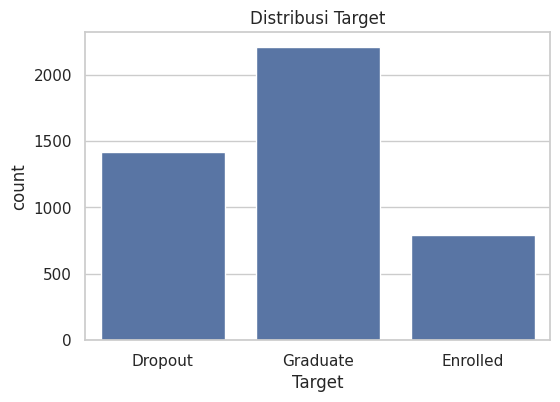

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='Target', data=df)

plt.title('Distribusi Target')
plt.show()

## 📊 Distribusi Status Mahasiswa

### Tujuan Analisis

Analisis ini dilakukan untuk mengetahui distribusi status akademik mahasiswa pada dataset yang digunakan. Status akademik dibagi menjadi tiga kategori, yaitu **Graduate** (lulus), **Dropout** (putus studi), dan **Enrolled** (masih aktif menempuh studi).

### Hasil Visualisasi

Berdasarkan grafik distribusi target, terdapat **2.209 mahasiswa (49,93%)** yang berstatus **Graduate**, **1.421 mahasiswa (32,12%)** yang berstatus **Dropout**, dan **794 mahasiswa (17,95%)** yang berstatus **Enrolled**.

Kategori **Graduate** merupakan kelompok terbesar dalam dataset, menunjukkan bahwa hampir setengah dari mahasiswa berhasil menyelesaikan studinya. Namun, proporsi mahasiswa yang mengalami **dropout** juga tergolong cukup tinggi, yaitu lebih dari sepertiga jumlah mahasiswa yang berhasil lulus. Sementara itu, kategori **Enrolled** memiliki jumlah paling sedikit karena mahasiswa pada kelompok ini masih berada dalam proses pendidikan dan belum memiliki status akhir.

### Insight

* Sebanyak **49,93%** mahasiswa berhasil menyelesaikan studi dan berstatus **Graduate**.
* Sebanyak **32,12%** mahasiswa mengalami **Dropout**, menunjukkan bahwa risiko putus studi masih menjadi permasalahan yang signifikan.
* Sebanyak **17,95%** mahasiswa masih berstatus **Enrolled** atau aktif menjalani perkuliahan.
* Tingginya jumlah mahasiswa yang mengalami dropout mengindikasikan adanya faktor-faktor akademik, finansial, maupun sosial yang berpotensi memengaruhi keberhasilan studi mahasiswa.

### Implikasi terhadap Proyek

Proporsi mahasiswa yang mengalami **dropout** cukup besar sehingga dataset ini sangat relevan untuk pengembangan model **Student Performance & Dropout Risk Prediction**. Model yang dibangun diharapkan mampu mengidentifikasi mahasiswa yang berisiko mengalami putus studi sejak dini sehingga institusi pendidikan dapat memberikan pendampingan, bantuan finansial, atau intervensi akademik yang lebih tepat sasaran.

### Kesimpulan

Distribusi status mahasiswa menunjukkan bahwa meskipun sebagian besar mahasiswa berhasil lulus, tingkat dropout masih tergolong tinggi dengan proporsi mencapai **32,12%** dari keseluruhan data. Temuan ini menunjukkan bahwa prediksi risiko dropout merupakan permasalahan yang penting untuk diteliti dan memiliki potensi manfaat yang besar bagi institusi pendidikan dalam meningkatkan tingkat keberhasilan studi mahasiswa.


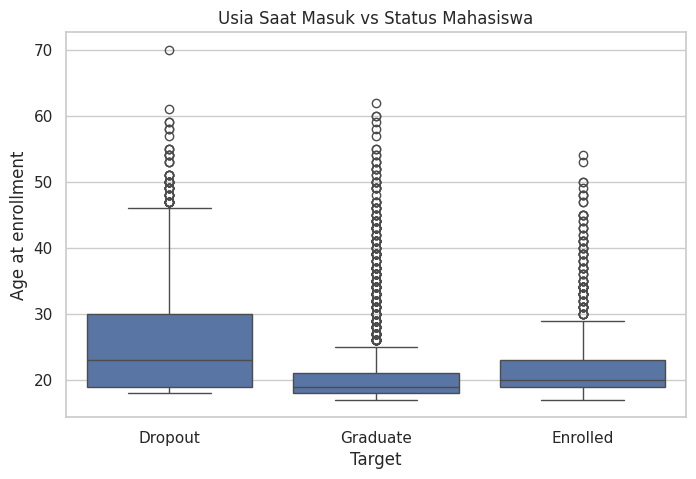

In [8]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Target',
    y='Age at enrollment',
    data=df
)

plt.title('Usia Saat Masuk vs Status Mahasiswa')
plt.show()

## 📊 Usia Saat Masuk Kuliah vs Status Mahasiswa

### Tujuan Analisis

Analisis ini dilakukan untuk mengetahui apakah terdapat perbedaan usia saat pertama kali masuk kuliah (**Age at enrollment**) pada mahasiswa dengan status akademik yang berbeda, yaitu **Graduate**, **Dropout**, dan **Enrolled**.

### Hasil Visualisasi

Berdasarkan boxplot yang ditampilkan, kelompok mahasiswa **Dropout** memiliki median usia masuk kuliah yang lebih tinggi dibandingkan kelompok **Graduate** dan **Enrolled**. Selain itu, rentang usia pada kelompok Dropout juga terlihat lebih lebar, menunjukkan variasi usia yang lebih besar dibandingkan kelompok lainnya.

Kelompok **Graduate** cenderung memiliki usia masuk yang lebih muda dan lebih terkonsentrasi pada rentang usia tertentu. Sementara itu, kelompok **Enrolled** memiliki distribusi usia yang berada di antara kelompok Graduate dan Dropout.

Grafik juga menunjukkan adanya sejumlah **outlier** pada ketiga kelompok, terutama pada kategori Dropout dan Graduate, yang mengindikasikan adanya mahasiswa yang memulai studi pada usia yang jauh lebih tinggi dibandingkan mayoritas mahasiswa lainnya.

### Insight

* Mahasiswa yang mengalami **Dropout** cenderung memiliki usia masuk kuliah yang lebih tinggi dibandingkan mahasiswa yang berhasil lulus.
* Variasi usia pada kelompok Dropout lebih besar dibandingkan kelompok lainnya.
* Kelompok **Graduate** memiliki distribusi usia yang relatif lebih rendah dan lebih stabil.
* Terdapat banyak mahasiswa dengan usia masuk di atas rata-rata (outlier), terutama pada kelompok Dropout.

### Interpretasi

Temuan ini mengindikasikan bahwa usia saat masuk kuliah dapat menjadi salah satu faktor yang berkaitan dengan keberhasilan studi mahasiswa. Mahasiswa yang memulai pendidikan tinggi pada usia yang lebih tua kemungkinan menghadapi tantangan tambahan, seperti tanggung jawab pekerjaan, kondisi ekonomi, atau kewajiban keluarga yang dapat memengaruhi keberlangsungan studi mereka.

Namun demikian, hubungan ini bersifat korelasional dan tidak dapat langsung disimpulkan sebagai hubungan sebab-akibat. Diperlukan analisis lebih lanjut terhadap faktor-faktor lain untuk memahami penyebab utama terjadinya dropout.

### Kesimpulan

Berdasarkan visualisasi, mahasiswa yang mengalami dropout cenderung memiliki usia masuk kuliah yang lebih tinggi dibandingkan mahasiswa yang berhasil lulus maupun yang masih aktif. Oleh karena itu, variabel **Age at enrollment** berpotensi menjadi salah satu fitur penting dalam model prediksi risiko dropout yang akan dibangun.


In [9]:
(
    pd.crosstab(
        df['Scholarship holder'],
        df['Target'],
        normalize='index'
    ) * 100
).round(2)

Target,Dropout,Enrolled,Graduate
Scholarship holder,,,
0,38.71,19.97,41.32
1,12.19,11.83,75.98


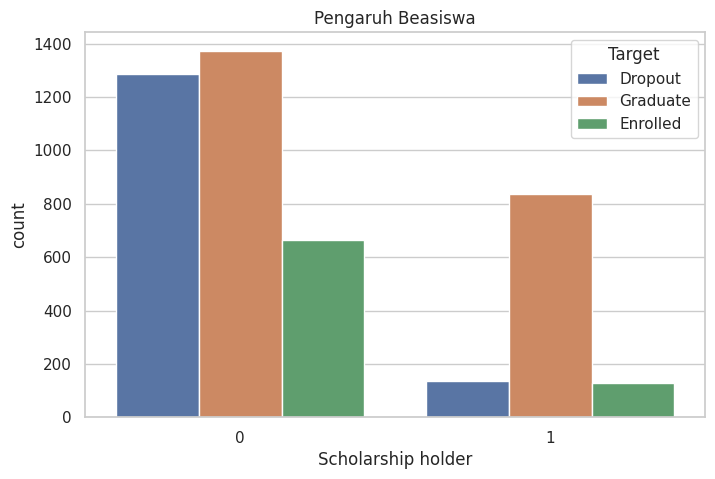

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Scholarship holder',
    hue='Target',
    data=df
)

plt.title('Pengaruh Beasiswa')
plt.show()

## 📊 Pengaruh Status Penerima Beasiswa terhadap Status Mahasiswa

### Tujuan Analisis

Analisis ini dilakukan untuk mengetahui hubungan antara status penerima beasiswa (**Scholarship holder**) dengan status akademik mahasiswa (**Graduate**, **Dropout**, dan **Enrolled**).

### Hasil Visualisasi

Berdasarkan tabel persentase dan grafik, mahasiswa yang menerima beasiswa memiliki tingkat kelulusan yang lebih tinggi dibandingkan mahasiswa yang tidak menerima beasiswa. Sebanyak **75,98%** penerima beasiswa berhasil lulus, sedangkan hanya **12,19%** yang mengalami dropout.

Sebaliknya, pada kelompok mahasiswa yang tidak menerima beasiswa, tingkat dropout mencapai **38,71%**, jauh lebih tinggi dibandingkan kelompok penerima beasiswa.

### Insight

* Tingkat kelulusan mahasiswa penerima beasiswa mencapai **75,98%**.
* Tingkat dropout mahasiswa penerima beasiswa hanya **12,19%**.
* Mahasiswa tanpa beasiswa memiliki tingkat dropout yang lebih tinggi, yaitu **38,71%**.
* Status penerima beasiswa menunjukkan hubungan positif dengan keberhasilan studi mahasiswa.

### Kesimpulan

Mahasiswa yang menerima beasiswa cenderung memiliki tingkat kelulusan yang lebih tinggi dan risiko dropout yang lebih rendah dibandingkan mahasiswa yang tidak menerima beasiswa. Oleh karena itu, variabel **Scholarship holder** berpotensi menjadi salah satu faktor penting dalam memprediksi risiko dropout mahasiswa.


In [11]:
(
    pd.crosstab(
        df['Tuition fees up to date'],
        df['Target'],
        normalize='index'
    ) * 100
).round(2)

Target,Dropout,Enrolled,Graduate
Tuition fees up to date,,,
0,86.55,7.95,5.49
1,24.74,19.30,55.95


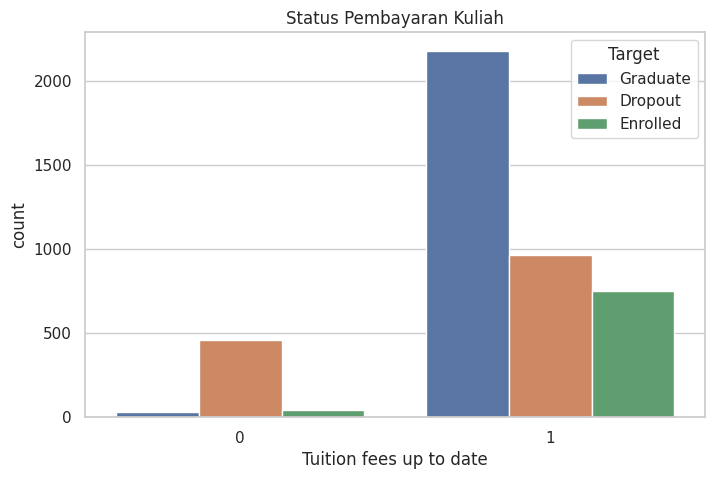

In [12]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Tuition fees up to date',
    hue='Target',
    data=df
)

plt.title('Status Pembayaran Kuliah')
plt.show()

## 📊 Pengaruh Status Pembayaran Kuliah terhadap Status Mahasiswa

### Tujuan Analisis

Analisis ini dilakukan untuk mengetahui hubungan antara status pembayaran kuliah (**Tuition fees up to date**) dengan status akademik mahasiswa (**Graduate**, **Dropout**, dan **Enrolled**).

### Hasil Visualisasi

Berdasarkan tabel persentase dan grafik, terlihat perbedaan yang sangat signifikan antara mahasiswa yang memiliki tunggakan pembayaran dan mahasiswa yang pembayaran kuliahnya sudah lunas.

Sebanyak **86,55%** mahasiswa yang memiliki tunggakan pembayaran mengalami **dropout**, sedangkan hanya **5,49%** yang berhasil lulus. Sebaliknya, pada kelompok mahasiswa yang pembayaran kuliahnya sudah lunas, **55,95%** berhasil lulus dan hanya **24,74%** yang mengalami dropout.

### Insight

* Tingkat dropout mahasiswa yang memiliki tunggakan pembayaran mencapai **86,55%**.
* Hanya **5,49%** mahasiswa dengan tunggakan pembayaran yang berhasil lulus.
* Mahasiswa yang pembayaran kuliahnya sudah lunas memiliki tingkat kelulusan lebih tinggi (**55,95%**).
* Status pembayaran kuliah menunjukkan hubungan yang sangat kuat dengan keberhasilan studi mahasiswa.

### Kesimpulan

Mahasiswa yang memiliki tunggakan pembayaran kuliah cenderung memiliki risiko dropout yang jauh lebih tinggi dibandingkan mahasiswa yang pembayaran kuliahnya sudah lunas. Temuan ini menunjukkan bahwa variabel **Tuition fees up to date** berpotensi menjadi salah satu faktor paling penting dalam model prediksi risiko dropout mahasiswa.


In [13]:
(
    pd.crosstab(
        df['Debtor'],
        df['Target'],
        normalize='index'
    ) * 100
).round(2)

Target,Dropout,Enrolled,Graduate
Debtor,,,
0,28.28,17.95,53.76
1,62.03,17.89,20.08


In [14]:
pd.crosstab(
    df['Debtor'],
    df['Target']
)

Target,Dropout,Enrolled,Graduate
Debtor,,,
0,1109,704,2108
1,312,90,101


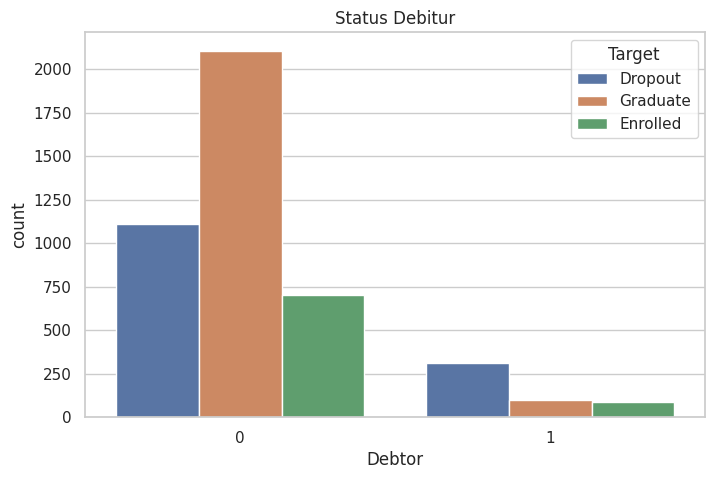

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Debtor',
    hue='Target',
    data=df
)

plt.title('Status Debitur')
plt.show()

## 📊 Pengaruh Status Debitur terhadap Status Mahasiswa

### Tujuan Analisis

Analisis ini dilakukan untuk mengetahui hubungan antara status debitur (**Debtor**) dengan status akademik mahasiswa (**Graduate**, **Dropout**, dan **Enrolled**).

### Hasil Visualisasi

Berdasarkan tabel persentase dan grafik, terlihat perbedaan yang cukup signifikan antara mahasiswa yang memiliki status debitur dan yang tidak.

Pada kelompok mahasiswa yang **bukan debitur** (nilai 0), mayoritas mahasiswa berhasil lulus dengan persentase **53,76%**, sedangkan **28,28%** mengalami dropout. Sebaliknya, pada kelompok mahasiswa yang **berstatus debitur** (nilai 1), persentase dropout meningkat menjadi **62,03%**, sementara tingkat kelulusan hanya **20,08%**.

### Insight

* Sebanyak **62,03%** mahasiswa yang berstatus debitur mengalami dropout.
* Hanya **20,08%** mahasiswa berstatus debitur yang berhasil lulus.
* Mahasiswa yang tidak memiliki status debitur memiliki tingkat kelulusan lebih tinggi (**53,76%**).
* Status debitur menunjukkan hubungan yang cukup kuat dengan risiko dropout mahasiswa.

### Kesimpulan

Mahasiswa yang memiliki status debitur cenderung memiliki risiko dropout yang lebih tinggi dibandingkan mahasiswa yang tidak memiliki status debitur. Oleh karena itu, variabel **Debtor** berpotensi menjadi salah satu faktor penting dalam model prediksi risiko dropout mahasiswa.


In [16]:
df.groupby('Target')[
    'Curricular units 1st sem (grade)'
].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Target,,,,,,,,
Dropout,1421.0,7.26,6.03,0.0,0.00,10.93,12.20,18.00
Enrolled,794.0,11.13,3.68,0.0,11.00,12.00,12.86,17.00
Graduate,2209.0,12.64,2.70,0.0,12.12,13.00,13.86,18.88


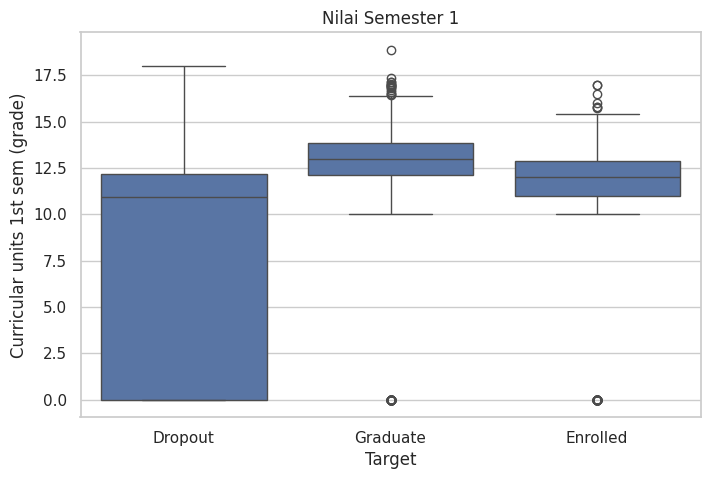

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Target',
    y='Curricular units 1st sem (grade)',
    data=df
)

plt.title('Nilai Semester 1')
plt.show()

## 📊 Pengaruh Nilai Semester 1 terhadap Status Mahasiswa

### Tujuan Analisis

Analisis ini dilakukan untuk mengetahui hubungan antara nilai semester pertama (**Curricular units 1st sem (grade)**) dengan status akademik mahasiswa (**Graduate**, **Dropout**, dan **Enrolled**).

### Hasil Visualisasi

Berdasarkan statistik deskriptif dan boxplot, mahasiswa yang berstatus **Graduate** memiliki rata-rata nilai semester pertama tertinggi yaitu **12,64**, diikuti oleh mahasiswa **Enrolled** sebesar **11,13**, dan mahasiswa **Dropout** sebesar **7,26**.

Selain itu, median nilai mahasiswa Graduate (**13,00**) juga lebih tinggi dibandingkan Enrolled (**12,00**) dan Dropout (**10,93**). Hal ini menunjukkan adanya perbedaan performa akademik yang cukup jelas antar kelompok mahasiswa.

### Insight

* Mahasiswa **Graduate** memiliki rata-rata nilai semester pertama tertinggi (**12,64**).
* Mahasiswa **Dropout** memiliki rata-rata nilai semester pertama terendah (**7,26**).
* Semakin tinggi nilai semester pertama, semakin besar kecenderungan mahasiswa untuk berhasil menyelesaikan studi.
* Performa akademik pada semester pertama menunjukkan hubungan yang kuat dengan status akademik mahasiswa.

### Kesimpulan

Mahasiswa yang memiliki nilai semester pertama lebih tinggi cenderung memiliki peluang kelulusan yang lebih besar, sedangkan mahasiswa dengan nilai yang lebih rendah memiliki risiko dropout yang lebih tinggi. Oleh karena itu, variabel **Curricular units 1st sem (grade)** berpotensi menjadi salah satu faktor penting dalam model prediksi risiko dropout mahasiswa.


In [18]:
df.groupby('Target')[
    'Curricular units 1st sem (approved)'
].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Target,,,,,,,,
Dropout,1421.0,2.55,2.86,0.0,0.0,2.0,4.0,21.0
Enrolled,794.0,4.32,2.29,0.0,3.0,5.0,6.0,15.0
Graduate,2209.0,6.23,2.58,0.0,5.0,6.0,7.0,26.0


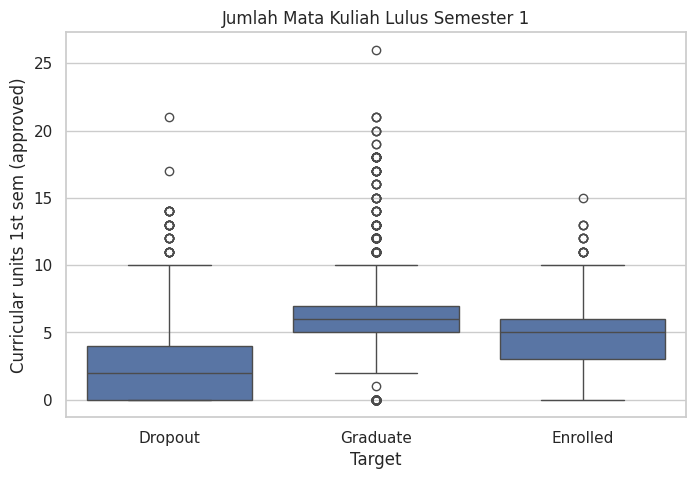

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Target',
    y='Curricular units 1st sem (approved)',
    data=df
)

plt.title('Jumlah Mata Kuliah Lulus Semester 1')
plt.show()

## 📊 Pengaruh Jumlah Mata Kuliah Lulus Semester 1 terhadap Status Mahasiswa

### Tujuan Analisis

Analisis ini dilakukan untuk mengetahui hubungan antara jumlah mata kuliah yang berhasil lulus pada semester pertama (**Curricular units 1st sem (approved)**) dengan status akademik mahasiswa (**Graduate**, **Dropout**, dan **Enrolled**).

### Hasil Visualisasi

Berdasarkan statistik deskriptif dan boxplot, mahasiswa yang berstatus **Graduate** memiliki rata-rata jumlah mata kuliah lulus semester pertama tertinggi yaitu **6,23 mata kuliah**, diikuti oleh mahasiswa **Enrolled** sebesar **4,32 mata kuliah**, dan mahasiswa **Dropout** sebesar **2,55 mata kuliah**.

Selain itu, median jumlah mata kuliah lulus pada kelompok Graduate adalah **6 mata kuliah**, sedangkan pada kelompok Dropout hanya **2 mata kuliah**. Perbedaan ini menunjukkan adanya kesenjangan performa akademik yang cukup besar antar kelompok mahasiswa.

### Insight

* Mahasiswa **Graduate** memiliki rata-rata jumlah mata kuliah lulus semester pertama tertinggi (**6,23 mata kuliah**).
* Mahasiswa **Dropout** hanya mampu menyelesaikan rata-rata **2,55 mata kuliah** pada semester pertama.
* Mahasiswa yang berhasil menyelesaikan lebih banyak mata kuliah pada semester pertama cenderung memiliki peluang kelulusan yang lebih tinggi.
* Jumlah mata kuliah lulus semester pertama menunjukkan hubungan yang kuat dengan status akademik mahasiswa.

### Kesimpulan

Mahasiswa yang mampu menyelesaikan lebih banyak mata kuliah pada semester pertama cenderung memiliki peluang yang lebih besar untuk lulus, sedangkan mahasiswa dengan jumlah mata kuliah lulus yang rendah memiliki risiko dropout yang lebih tinggi. Oleh karena itu, variabel **Curricular units 1st sem (approved)** berpotensi menjadi salah satu faktor penting dalam model prediksi risiko dropout mahasiswa.


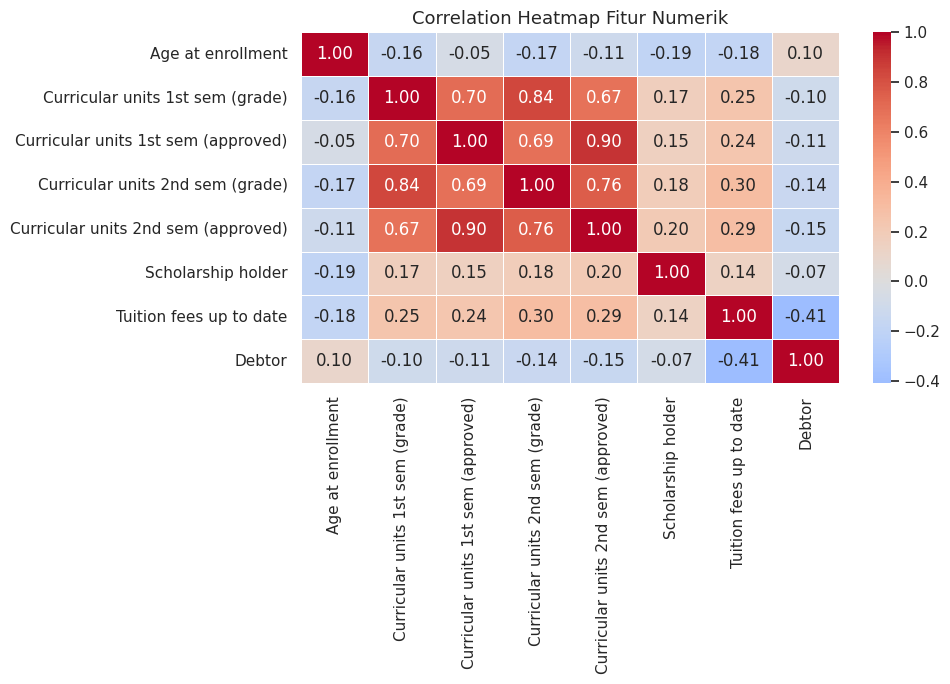

In [21]:
# Pilih fitur numerik yang relevan
numeric_cols = [
    "Age at enrollment",
    "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (approved)",
    "Curricular units 2nd sem (grade)",
    "Curricular units 2nd sem (approved)",
    "Scholarship holder",
    "Tuition fees up to date",
    "Debtor",
]

plt.figure(figsize=(10, 7))

corr_matrix = df[numeric_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap Fitur Numerik", fontsize=13)
plt.tight_layout()
plt.show()

## 📊 Correlation Heatmap Fitur Numerik

### Tujuan Analisis

Analisis korelasi dilakukan untuk mengukur hubungan linear antara fitur-fitur numerik dalam dataset. Heatmap ini membantu mengidentifikasi pasangan fitur yang saling berkorelasi kuat sebagai pertimbangan dalam *feature selection* pada tahap pemodelan.

### Insight

* **Nilai dan jumlah mata kuliah lulus** semester 1 menunjukkan korelasi positif yang kuat — mahasiswa dengan nilai tinggi cenderung menyelesaikan lebih banyak mata kuliah.
* **Tuition fees up to date** berkorelasi negatif dengan **Debtor** — mahasiswa yang membayar tepat waktu cenderung tidak berstatus debitur.
* **Age at enrollment** menunjukkan korelasi negatif dengan performa akademik, mengkonfirmasi temuan pada visualisasi sebelumnya.
* Pola korelasi fitur semester 1 dan semester 2 terlihat konsisten, menunjukkan performa akademik yang cenderung stabil antar semester.

### Kesimpulan

Fitur akademik dan finansial saling berkaitan satu sama lain. Pemahaman pola korelasi ini akan membantu proses seleksi dan rekayasa fitur (*feature engineering*) pada tahap pemodelan berikutnya.

## Kesimpulan EDA

Berdasarkan hasil analisis eksploratif data (EDA), ditemukan beberapa faktor yang memiliki hubungan kuat dengan risiko dropout mahasiswa.

Faktor finansial seperti status pembayaran kuliah, status debitur, dan penerimaan beasiswa menunjukkan pengaruh yang signifikan terhadap status akademik mahasiswa.

Selain itu, performa akademik pada semester pertama, baik dari sisi nilai maupun jumlah mata kuliah yang berhasil diselesaikan, juga memiliki hubungan yang kuat dengan kemungkinan mahasiswa menyelesaikan studi.

Temuan ini menunjukkan bahwa faktor akademik dan finansial berpotensi menjadi prediktor utama dalam model Student Performance & Dropout Risk Prediction.